# Convolutional Neural Networks for Digit and Fashion Classification

**Context:** Guided image-classification activities, consolidated and extended for portfolio presentation  
**Tools:** Python, TensorFlow/Keras, pandas, NumPy, scikit-learn, Matplotlib, seaborn  
**Methods:** convolutional neural networks, stratified validation, multiclass evaluation,
confusion matrices, per-class recall, and error analysis

## TL;DR

**Validated results:** the digit CNN achieved 97.67% accuracy and 0.0764 log-loss on a stratified 6,300-image validation set. It also generated 28,000 predictions for the unlabelled competition file. The independently built Fashion-MNIST CNN achieved 86.81% accuracy and 0.3684 log-loss on the official 10,000-image test set.

## Context & Methods

This notebook develops two related image-classification studies:

1. train a CNN on labelled 28 x 28 digit images supplied in CSV format and generate
   predictions for an unlabelled competition-style test file; and
2. independently build and evaluate a CNN on Fashion-MNIST.

### Key assumptions and safeguards

- The digit CSV files follow the common `label` plus `pixel0`–`pixel783` schema.
- Because the supplied digit test file has no labels, model quality is measured on a
  stratified validation split from the labelled training data. The unlabelled file is used
  only to demonstrate prediction generation.
- Fashion-MNIST keeps its official 10,000-image test partition untouched until final
  evaluation.
- Pixel values are scaled from 0–255 to 0–1.
- Sparse categorical cross-entropy is used so labels do not need one-hot encoding.
- Accuracy is paired with log-loss, confusion matrices, per-class recall, and visible errors.
- Fixed random seeds improve repeatability; minor hardware-dependent differences can remain.

These are compact educational models, not production systems or architecture benchmarks.

## Setup & Data Sources

The digit CSV files are intentionally not redistributed in this repository because their
licensing and original download provenance were not supplied. Set `DIGITS_DATA_DIR` to the
folder containing `train.csv` and `test.csv` before running.

Fashion-MNIST is loaded through TensorFlow/Keras.

References:

- [Kaggle Digit Recognizer](https://www.kaggle.com/competitions/digit-recognizer)
- [Keras Fashion-MNIST loader](https://keras.io/api/datasets/fashion_mnist/)
- [TensorFlow CNN tutorial](https://www.tensorflow.org/tutorials/images/cnn)

In [1]:
import os
from pathlib import Path

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "8")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import tensorflow as tf
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    log_loss,
    recall_score,
)
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers

RANDOM_STATE = 42
keras.utils.set_random_seed(RANDOM_STATE)

pd.set_option("display.precision", 4)
sns.set_theme(style="whitegrid", context="notebook")

print(f"TensorFlow version: {tf.__version__}")
print(f"scikit-learn version: {sklearn.__version__}")
print("Compute devices:", [device.device_type for device in tf.config.list_physical_devices()])

TensorFlow version: 2.19.1
scikit-learn version: 1.9.0
Compute devices: ['CPU']


## Study 1 — Digit Classification from CSV Files

In [2]:
digits_data_dir = Path(os.getenv("DIGITS_DATA_DIR", "data"))
digits_train_path = digits_data_dir / "train.csv"
digits_competition_path = digits_data_dir / "test.csv"

if not digits_train_path.exists() or not digits_competition_path.exists():
    raise FileNotFoundError(
        "Set DIGITS_DATA_DIR to the folder containing train.csv and test.csv."
    )

digits_train_frame = pd.read_csv(digits_train_path, dtype=np.uint8)
digits_competition_frame = pd.read_csv(digits_competition_path, dtype=np.uint8)

expected_pixel_columns = [f"pixel{index}" for index in range(784)]
assert digits_train_frame.columns.tolist() == ["label", *expected_pixel_columns]
assert digits_competition_frame.columns.tolist() == expected_pixel_columns
assert digits_train_frame.isna().sum().sum() == 0
assert digits_competition_frame.isna().sum().sum() == 0

digits_profile = pd.Series(
    {
        "labelled_rows": len(digits_train_frame),
        "unlabelled_rows": len(digits_competition_frame),
        "pixel_columns": len(expected_pixel_columns),
        "classes": digits_train_frame["label"].nunique(),
        "minimum_pixel": digits_train_frame[expected_pixel_columns].min().min(),
        "maximum_pixel": digits_train_frame[expected_pixel_columns].max().max(),
        "missing_values": int(
            digits_train_frame.isna().sum().sum()
            + digits_competition_frame.isna().sum().sum()
        ),
    }
)
digits_profile

labelled_rows      42000
unlabelled_rows    28000
pixel_columns        784
classes               10
minimum_pixel          0
maximum_pixel        255
missing_values         0
dtype: uint64

In [3]:
digits_images = digits_train_frame[expected_pixel_columns].to_numpy().reshape(-1, 28, 28, 1)
digits_labels = digits_train_frame["label"].to_numpy()
digits_competition_images = (
    digits_competition_frame[expected_pixel_columns]
    .to_numpy()
    .reshape(-1, 28, 28, 1)
)

(
    digits_training_images,
    digits_validation_images,
    digits_training_labels,
    digits_validation_labels,
) = train_test_split(
    digits_images,
    digits_labels,
    test_size=0.15,
    stratify=digits_labels,
    random_state=RANDOM_STATE,
)

digits_training_images = digits_training_images.astype("float32") / 255.0
digits_validation_images = digits_validation_images.astype("float32") / 255.0
digits_competition_images = digits_competition_images.astype("float32") / 255.0

del digits_train_frame, digits_competition_frame, digits_images

pd.Series(
    {
        "training_rows": len(digits_training_images),
        "validation_rows": len(digits_validation_images),
        "competition_rows": len(digits_competition_images),
        "training_class_minimum": int(
            np.bincount(digits_training_labels, minlength=10).min()
        ),
        "training_class_maximum": int(
            np.bincount(digits_training_labels, minlength=10).max()
        ),
    }
)

training_rows             35700
validation_rows            6300
competition_rows          28000
training_class_minimum     3226
training_class_maximum     3981
dtype: int64

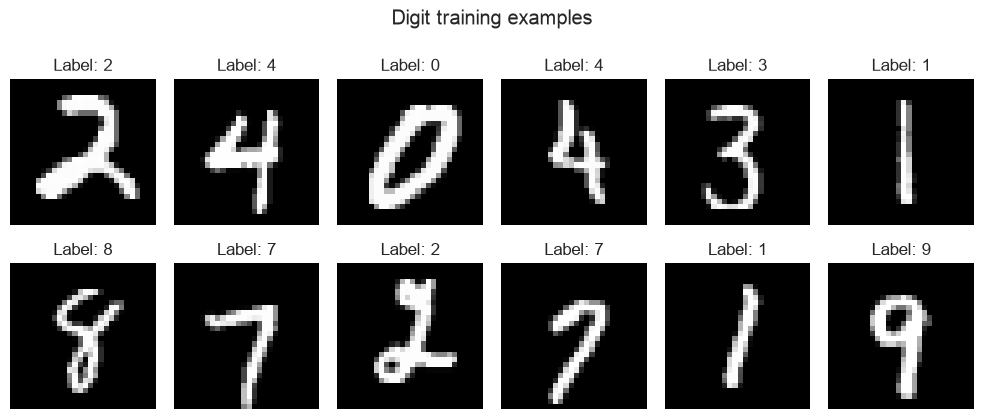

In [4]:
fig, axes = plt.subplots(2, 6, figsize=(10, 4.5))
for axis, image, label in zip(
    axes.ravel(), digits_training_images[:12], digits_training_labels[:12]
):
    axis.imshow(image.squeeze(), cmap="gray")
    axis.set_title(f"Label: {label}")
    axis.axis("off")
plt.suptitle("Digit training examples")
plt.tight_layout()
plt.show()

In [5]:
def build_cnn(model_name: str) -> keras.Sequential:
    model = keras.Sequential(
        [
            keras.Input(shape=(28, 28, 1)),
            layers.Conv2D(16, 3, padding="same", activation="relu"),
            layers.MaxPooling2D(),
            layers.Conv2D(32, 3, padding="same", activation="relu"),
            layers.MaxPooling2D(),
            layers.Dropout(0.20),
            layers.Flatten(),
            layers.Dense(64, activation="relu"),
            layers.Dropout(0.30),
            layers.Dense(10, activation="softmax"),
        ],
        name=model_name,
    )
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


digits_model = build_cnn("digit_cnn")
digits_history = digits_model.fit(
    digits_training_images,
    digits_training_labels,
    validation_data=(digits_validation_images, digits_validation_labels),
    epochs=3,
    batch_size=256,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=1,
            restore_best_weights=True,
        )
    ],
    verbose=2,
)

print("Trainable parameters:", digits_model.count_params())

Epoch 1/3


140/140 - 3s - 19ms/step - accuracy: 0.7968 - loss: 0.6552 - val_accuracy: 0.9452 - val_loss: 0.1675


Epoch 2/3


140/140 - 2s - 14ms/step - accuracy: 0.9410 - loss: 0.1946 - val_accuracy: 0.9716 - val_loss: 0.0973


Epoch 3/3


140/140 - 2s - 16ms/step - accuracy: 0.9597 - loss: 0.1294 - val_accuracy: 0.9767 - val_loss: 0.0764


Trainable parameters: 105866


In [6]:
digits_validation_loss, digits_validation_accuracy = digits_model.evaluate(
    digits_validation_images,
    digits_validation_labels,
    batch_size=512,
    verbose=0,
)
digits_validation_probabilities = digits_model.predict(
    digits_validation_images,
    batch_size=512,
    verbose=0,
)
digits_validation_predictions = digits_validation_probabilities.argmax(axis=1)
digits_sklearn_log_loss = log_loss(
    digits_validation_labels,
    digits_validation_probabilities,
    labels=np.arange(10),
)

assert np.isclose(
    digits_validation_accuracy,
    accuracy_score(digits_validation_labels, digits_validation_predictions),
)
assert np.isclose(digits_validation_loss, digits_sklearn_log_loss, atol=1e-5)

pd.Series(
    {
        "validation_cross_entropy": digits_validation_loss,
        "sklearn_log_loss_check": digits_sklearn_log_loss,
        "validation_accuracy": digits_validation_accuracy,
        "correct_predictions": int(
            (digits_validation_predictions == digits_validation_labels).sum()
        ),
        "validation_rows": len(digits_validation_labels),
    }
)

validation_cross_entropy       0.0764
sklearn_log_loss_check         0.0764
validation_accuracy            0.9767
correct_predictions         6153.0000
validation_rows             6300.0000
dtype: float64

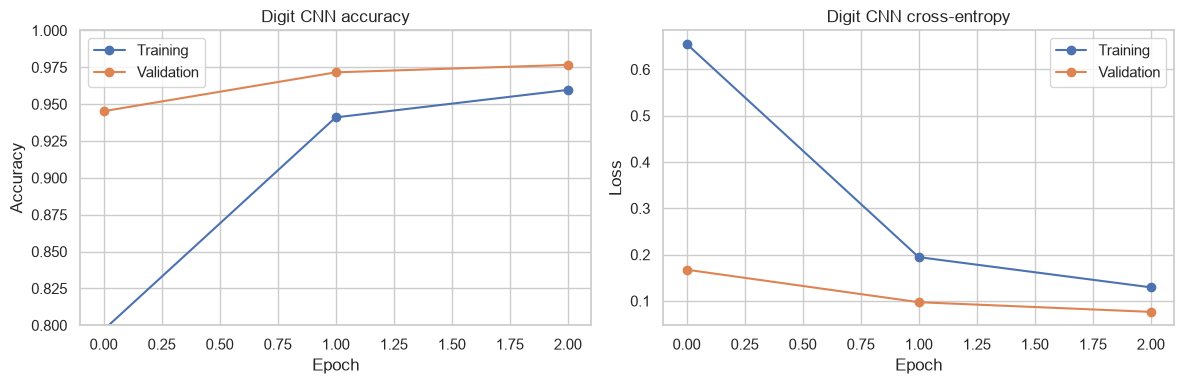

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(digits_history.history["accuracy"], marker="o", label="Training")
axes[0].plot(digits_history.history["val_accuracy"], marker="o", label="Validation")
axes[0].set(title="Digit CNN accuracy", xlabel="Epoch", ylabel="Accuracy", ylim=(0.8, 1.0))
axes[0].legend()

axes[1].plot(digits_history.history["loss"], marker="o", label="Training")
axes[1].plot(digits_history.history["val_loss"], marker="o", label="Validation")
axes[1].set(title="Digit CNN cross-entropy", xlabel="Epoch", ylabel="Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

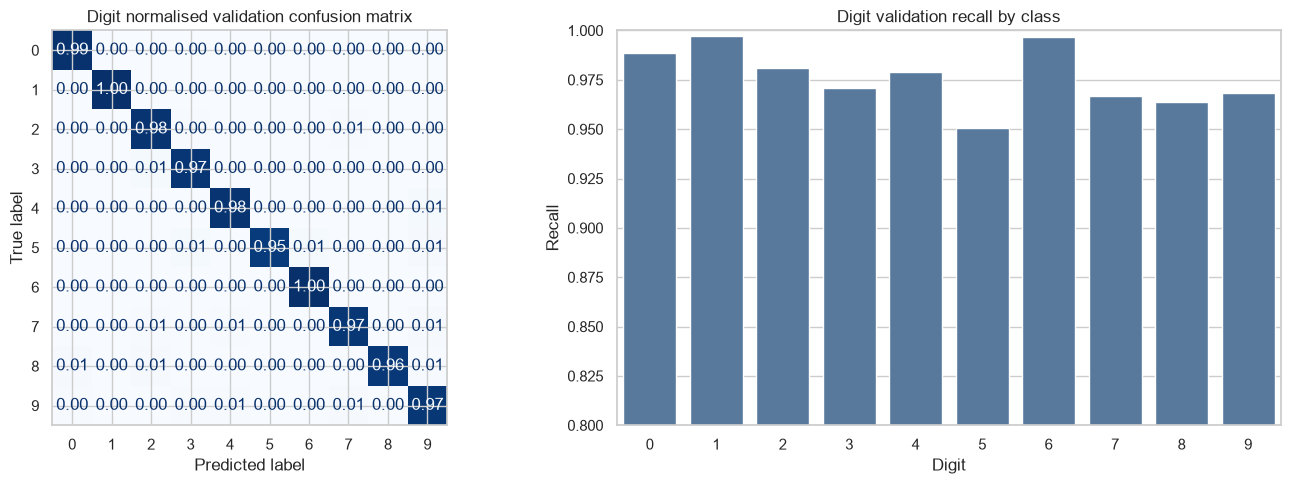

,digit,validation_recall
0,0,0.9887
1,1,0.9972
2,2,0.9809
3,3,0.9709
4,4,0.9787
5,5,0.9508
6,6,0.9968
7,7,0.9667
8,8,0.9639
9,9,0.9682


In [8]:
digits_class_recall = recall_score(
    digits_validation_labels,
    digits_validation_predictions,
    labels=np.arange(10),
    average=None,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(
    digits_validation_labels,
    digits_validation_predictions,
    labels=np.arange(10),
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title("Digit normalised validation confusion matrix")

sns.barplot(x=np.arange(10), y=digits_class_recall, color="#4C78A8", ax=axes[1])
axes[1].set(
    title="Digit validation recall by class",
    xlabel="Digit",
    ylabel="Recall",
    ylim=(0.8, 1.0),
)

plt.tight_layout()
plt.show()

pd.DataFrame({"digit": np.arange(10), "validation_recall": digits_class_recall}).round(4)

In [9]:
digits_competition_probabilities = digits_model.predict(
    digits_competition_images,
    batch_size=512,
    verbose=0,
)
digits_competition_predictions = digits_competition_probabilities.argmax(axis=1)

digits_submission_preview = pd.DataFrame(
    {
        "ImageId": np.arange(1, len(digits_competition_predictions) + 1),
        "Label": digits_competition_predictions,
    }
)

assert len(digits_submission_preview) == 28_000
assert digits_submission_preview["Label"].between(0, 9).all()

print("Prediction rows:", len(digits_submission_preview))
display(digits_submission_preview.head())
display(
    digits_submission_preview["Label"]
    .value_counts(normalize=True)
    .sort_index()
    .rename("prediction_share")
    .to_frame()
)

Prediction rows: 28000


,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,9
4,5,3


,prediction_share
Label,
0,0.0998
1,0.1153
2,0.1005
3,0.1000
4,0.0985
5,0.0884
6,0.0984
7,0.1030
8,0.0985


## Study 2 — Fashion-MNIST Classification

In [10]:
(fashion_images_full, fashion_labels_full), (
    fashion_test_images,
    fashion_test_labels,
) = keras.datasets.fashion_mnist.load_data()

(
    fashion_training_images,
    fashion_validation_images,
    fashion_training_labels,
    fashion_validation_labels,
) = train_test_split(
    fashion_images_full,
    fashion_labels_full,
    test_size=10_000,
    stratify=fashion_labels_full,
    random_state=RANDOM_STATE,
)

fashion_training_images = fashion_training_images[..., np.newaxis].astype("float32") / 255.0
fashion_validation_images = (
    fashion_validation_images[..., np.newaxis].astype("float32") / 255.0
)
fashion_test_images = fashion_test_images[..., np.newaxis].astype("float32") / 255.0

fashion_class_names = np.array(
    [
        "T-shirt/top",
        "Trouser",
        "Pullover",
        "Dress",
        "Coat",
        "Sandal",
        "Shirt",
        "Sneaker",
        "Bag",
        "Ankle boot",
    ]
)

pd.Series(
    {
        "training_rows": len(fashion_training_images),
        "validation_rows": len(fashion_validation_images),
        "test_rows": len(fashion_test_images),
        "image_shape": str(fashion_training_images.shape[1:]),
        "classes": len(fashion_class_names),
        "minimum_pixel": float(fashion_training_images.min()),
        "maximum_pixel": float(fashion_training_images.max()),
    }
)

training_rows            50000
validation_rows          10000
test_rows                10000
image_shape        (28, 28, 1)
classes                     10
minimum_pixel              0.0
maximum_pixel              1.0
dtype: object

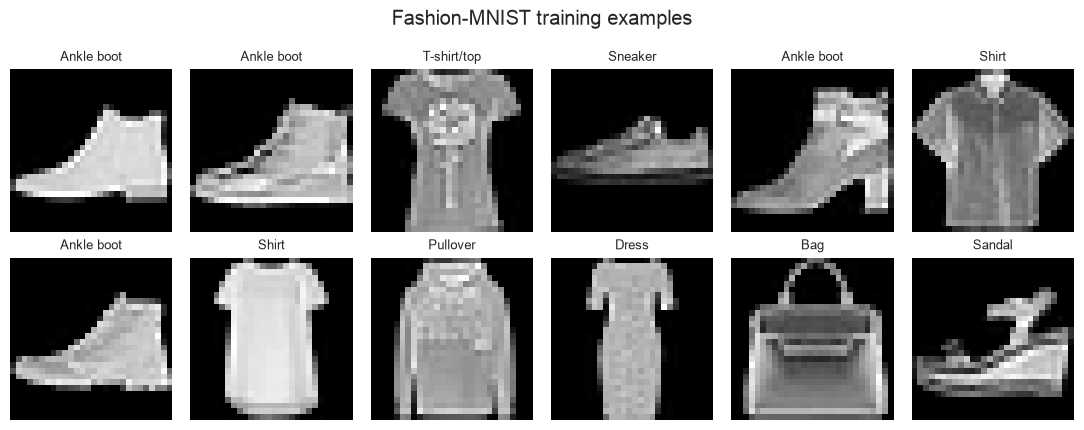

In [11]:
fig, axes = plt.subplots(2, 6, figsize=(11, 4.5))
for axis, image, label in zip(
    axes.ravel(), fashion_training_images[:12], fashion_training_labels[:12]
):
    axis.imshow(image.squeeze(), cmap="gray")
    axis.set_title(fashion_class_names[label], fontsize=9)
    axis.axis("off")
plt.suptitle("Fashion-MNIST training examples")
plt.tight_layout()
plt.show()

In [12]:
fashion_model = build_cnn("fashion_mnist_cnn")
fashion_history = fashion_model.fit(
    fashion_training_images,
    fashion_training_labels,
    validation_data=(fashion_validation_images, fashion_validation_labels),
    epochs=3,
    batch_size=256,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=1,
            restore_best_weights=True,
        )
    ],
    verbose=2,
)

print("Trainable parameters:", fashion_model.count_params())

Epoch 1/3


196/196 - 3s - 18ms/step - accuracy: 0.7058 - loss: 0.8079 - val_accuracy: 0.8383 - val_loss: 0.4583


Epoch 2/3


196/196 - 3s - 15ms/step - accuracy: 0.8243 - loss: 0.4915 - val_accuracy: 0.8698 - val_loss: 0.3734


Epoch 3/3


196/196 - 3s - 15ms/step - accuracy: 0.8467 - loss: 0.4312 - val_accuracy: 0.8811 - val_loss: 0.3370


Trainable parameters: 105866


In [13]:
fashion_test_loss, fashion_test_accuracy = fashion_model.evaluate(
    fashion_test_images,
    fashion_test_labels,
    batch_size=512,
    verbose=0,
)
fashion_test_probabilities = fashion_model.predict(
    fashion_test_images,
    batch_size=512,
    verbose=0,
)
fashion_test_predictions = fashion_test_probabilities.argmax(axis=1)
fashion_sklearn_log_loss = log_loss(
    fashion_test_labels,
    fashion_test_probabilities,
    labels=np.arange(10),
)

assert np.isclose(
    fashion_test_accuracy,
    accuracy_score(fashion_test_labels, fashion_test_predictions),
)
assert np.isclose(fashion_test_loss, fashion_sklearn_log_loss, atol=1e-5)

pd.Series(
    {
        "test_cross_entropy": fashion_test_loss,
        "sklearn_log_loss_check": fashion_sklearn_log_loss,
        "test_accuracy": fashion_test_accuracy,
        "correct_predictions": int(
            (fashion_test_predictions == fashion_test_labels).sum()
        ),
        "test_rows": len(fashion_test_labels),
    }
)

test_cross_entropy            0.3684
sklearn_log_loss_check        0.3684
test_accuracy                 0.8681
correct_predictions        8681.0000
test_rows                 10000.0000
dtype: float64

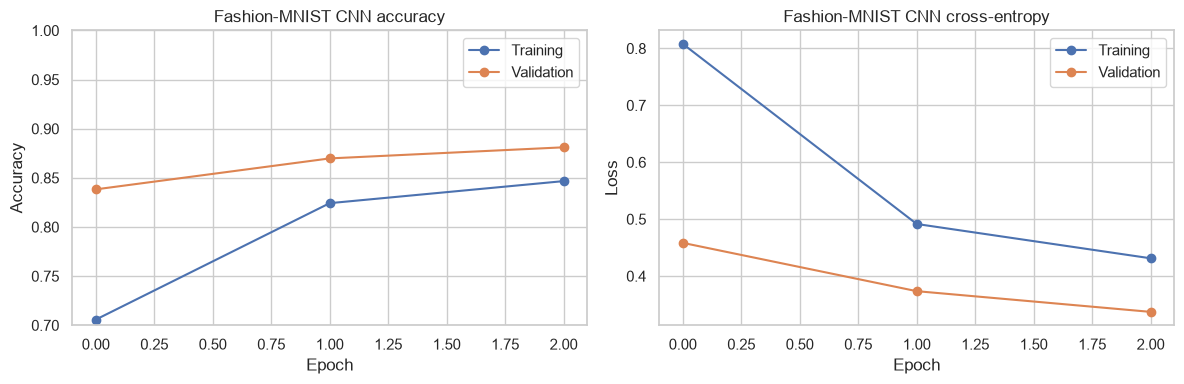

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(fashion_history.history["accuracy"], marker="o", label="Training")
axes[0].plot(fashion_history.history["val_accuracy"], marker="o", label="Validation")
axes[0].set(
    title="Fashion-MNIST CNN accuracy",
    xlabel="Epoch",
    ylabel="Accuracy",
    ylim=(0.7, 1.0),
)
axes[0].legend()

axes[1].plot(fashion_history.history["loss"], marker="o", label="Training")
axes[1].plot(fashion_history.history["val_loss"], marker="o", label="Validation")
axes[1].set(title="Fashion-MNIST CNN cross-entropy", xlabel="Epoch", ylabel="Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

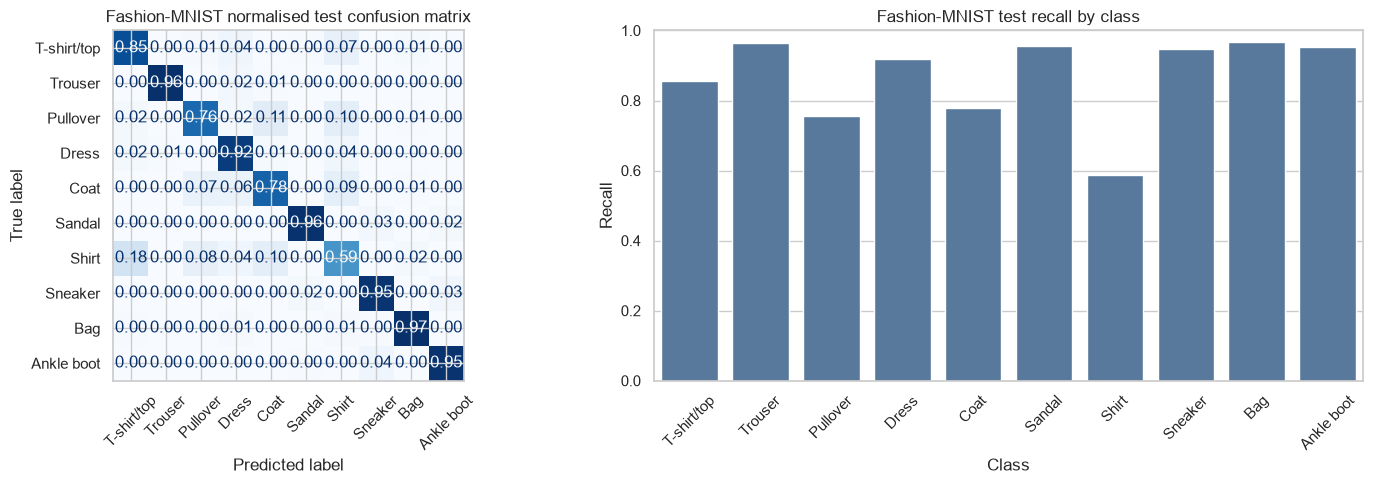

,class,test_recall
0,T-shirt/top,0.855
1,Trouser,0.965
2,Pullover,0.757
3,Dress,0.919
4,Coat,0.778
5,Sandal,0.956
6,Shirt,0.586
7,Sneaker,0.946
8,Bag,0.966
9,Ankle boot,0.953


In [15]:
fashion_class_recall = recall_score(
    fashion_test_labels,
    fashion_test_predictions,
    labels=np.arange(10),
    average=None,
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ConfusionMatrixDisplay.from_predictions(
    fashion_test_labels,
    fashion_test_predictions,
    labels=np.arange(10),
    display_labels=fashion_class_names,
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title("Fashion-MNIST normalised test confusion matrix")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(x=fashion_class_names, y=fashion_class_recall, color="#4C78A8", ax=axes[1])
axes[1].set(
    title="Fashion-MNIST test recall by class",
    xlabel="Class",
    ylabel="Recall",
    ylim=(0, 1),
)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

pd.DataFrame(
    {"class": fashion_class_names, "test_recall": fashion_class_recall}
).round(4)

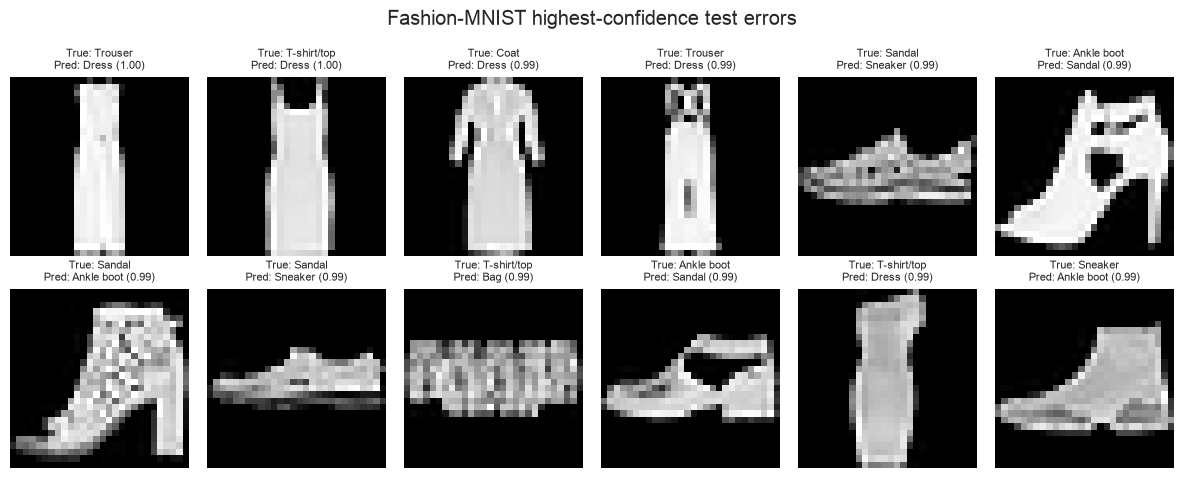

In [16]:
fashion_error_indices = np.flatnonzero(
    fashion_test_predictions != fashion_test_labels
)
fashion_error_confidence = fashion_test_probabilities[fashion_error_indices].max(axis=1)
fashion_high_confidence_errors = fashion_error_indices[
    np.argsort(fashion_error_confidence)[-12:][::-1]
]

fig, axes = plt.subplots(2, 6, figsize=(12, 5))
for axis, index in zip(axes.ravel(), fashion_high_confidence_errors):
    axis.imshow(fashion_test_images[index].squeeze(), cmap="gray")
    axis.set_title(
        f"True: {fashion_class_names[fashion_test_labels[index]]}\n"
        f"Pred: {fashion_class_names[fashion_test_predictions[index]]} "
        f"({fashion_test_probabilities[index].max():.2f})",
        fontsize=8,
    )
    axis.axis("off")
plt.suptitle("Fashion-MNIST highest-confidence test errors")
plt.tight_layout()
plt.show()

## Results Summary

In [17]:
final_metrics = pd.DataFrame(
    [
        {
            "study": "Digit CSV",
            "model": "Compact CNN",
            "evaluation_scope": f"{len(digits_validation_labels):,}-image validation set",
            "primary_metric": "Accuracy",
            "value": digits_validation_accuracy,
        },
        {
            "study": "Fashion-MNIST",
            "model": "Compact CNN",
            "evaluation_scope": f"{len(fashion_test_labels):,}-image official test set",
            "primary_metric": "Accuracy",
            "value": fashion_test_accuracy,
        },
    ]
)
final_metrics.round(4)

,study,model,evaluation_scope,primary_metric,value
0,Digit CSV,Compact CNN,"6,300-image validation set",Accuracy,0.9767
1,Fashion-MNIST,Compact CNN,"10,000-image official test set",Accuracy,0.8681


## Takeaways

1. **CNNs fit image structure better than immediate flattening.** Convolution and pooling
   preserve local spatial patterns before the classifier layers.
2. **Evaluation labels determine what can be claimed.** The digit CSV test file is unlabelled,
   so its predictions are generated but not scored; accuracy is reported only on the labelled
   validation set.
3. **Per-class results reveal the difficult categories.** Fashion-MNIST classes with similar
   silhouettes can be confused even when aggregate accuracy is strong.
4. **A baseline is a starting point.** More epochs, data augmentation, learning-rate schedules,
   and architecture comparison would be reasonable next experiments.

### Limitations

- A single seeded split and single training run do not quantify optimisation uncertainty.
- No Kaggle leaderboard score is claimed because no submission result was supplied.
- Dataset redistribution rights were not established, so the digit CSV files are excluded.
- Calibration, robustness to distribution shift, fairness, and deployment are out of scope.